# Fetal Health Classification with Perceptron

This notebook walks through **supervised perceptron classification** on the **Fetal Health** dataset. The original target has three labels; we merge it into a binary task: normal fetal health vs suspect/pathological fetal health.

The first code cell imports libraries and sets plot defaults. **Notebook outline:**

1. Load data and basic quality checks  
2. Exploratory analysis with class and feature plots  
3. Train / test split and feature standardization  
4. Fit a perceptron classifier from `rice_ml`  
5. Test-set evaluation and confusion matrix  
6. Visualizations of decision scores and feature weights  
7. Linear limitation: XOR  
8. Discussion and limitations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from rice_ml.processing.datasets import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

## 1. Load data and quality checks

We read `fetal_health.csv` via `find_data_file` so the notebook runs from the repo root, from this folder, or from Jupyter with any working directory. The binary label is `0` for normal and `1` for suspect or pathological.

In [2]:
from rice_ml.supervised_learning.perceptron import Perceptron
from rice_ml.processing.pre_processing import StandardScaler, train_test_split
from rice_ml.processing.post_processing import accuracy_score, confusion_matrix, precision_recall_f1


df = pd.read_csv(find_data_file("fetal_health.csv"))
df = df.dropna().copy()

feature_names = [col for col in df.columns if col != "fetal_health"]
y_multi = df["fetal_health"].to_numpy(dtype=int)
y = (y_multi > 1).astype(int)
df["binary_health"] = y

print("Shape:", df.shape)
print("Original fetal_health counts:")
print(df["fetal_health"].value_counts().sort_index())
print("\nBinary counts:")
print(df["binary_health"].value_counts().sort_index())

df.head()

Shape: (2126, 23)
Original fetal_health counts:
fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64

Binary counts:
binary_health
0    1655
1     471
Name: count, dtype: int64


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health,binary_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0,1
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0,0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0,0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0,0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0,0


## 2. Exploratory analysis

The perceptron learns a **linear** decision boundary, so plots are useful for seeing whether the binary classes look even roughly separable in common feature views. The scatter matrix uses only a few readable features rather than all 21 predictors.

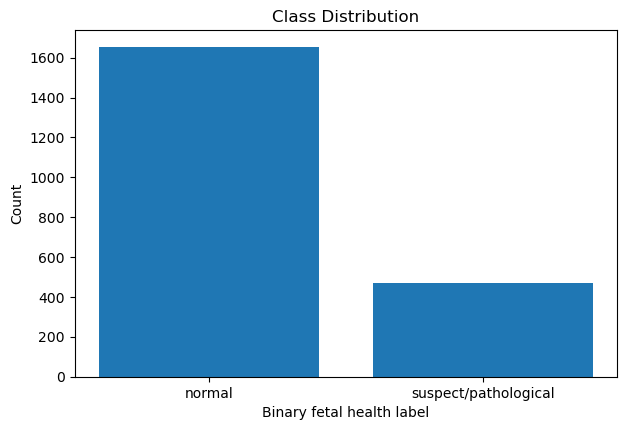

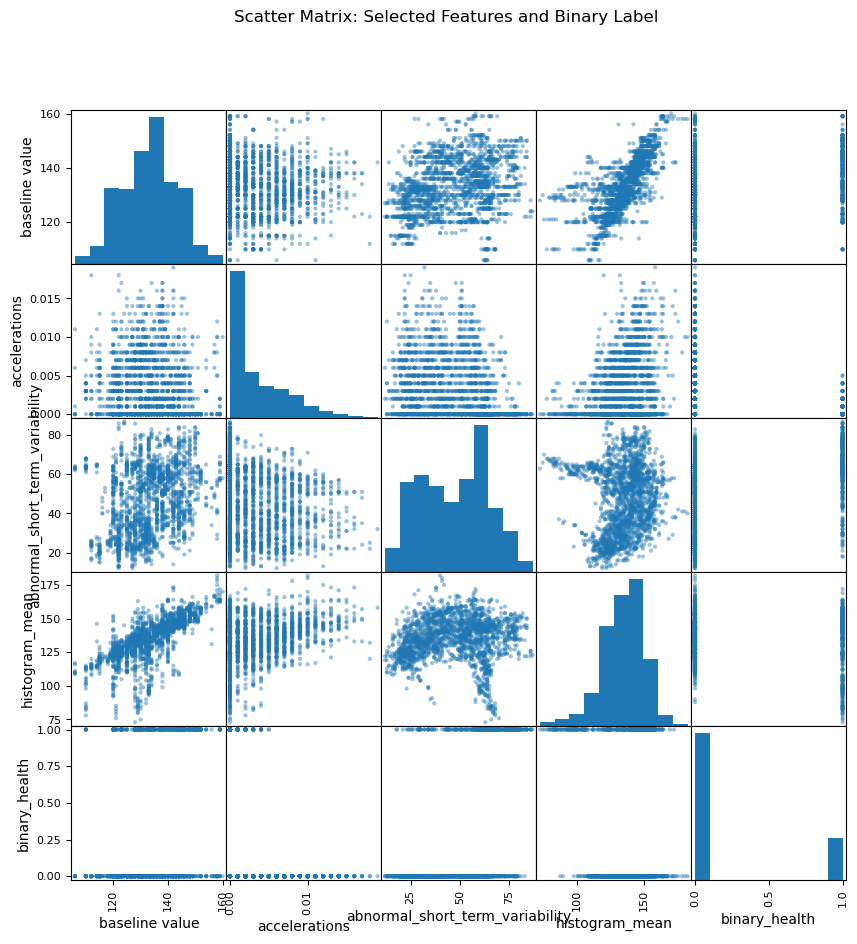

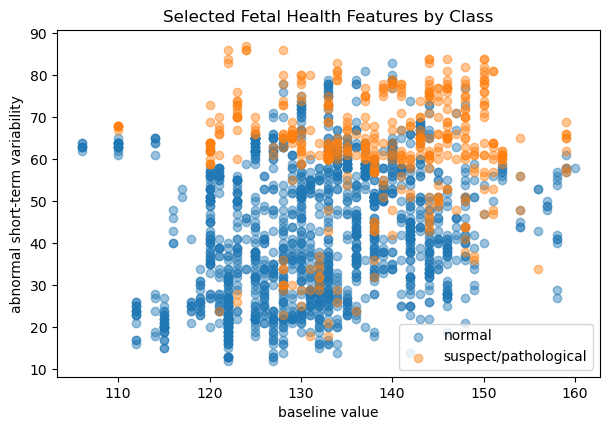

/var/folders/37/vd2xcb9d7v15dw6bcznn2ym80000gn/T/ipykernel_29521/2329192067.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[f] for f in plot_features], labels=plot_features)


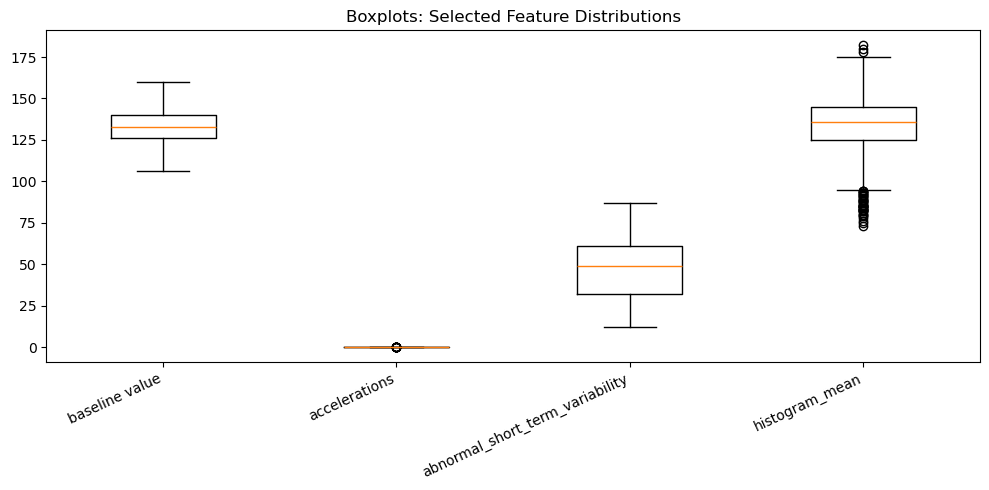

In [3]:
plot_features = [
    "baseline value",
    "accelerations",
    "abnormal_short_term_variability",
    "histogram_mean",
]

# Binary target distribution.
plt.figure()
plt.bar(["normal", "suspect/pathological"], df["binary_health"].value_counts().sort_index().values)
plt.xlabel("Binary fetal health label")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

# Scatter matrix for selected features and binary target.
scatter_matrix(df[plot_features + ["binary_health"]], figsize=(10, 10), diagonal="hist", alpha=0.45)
plt.suptitle("Scatter Matrix: Selected Features and Binary Label")
plt.show()

# Two-feature view colored by binary class.
for cls, label, color in [(0, "normal", "tab:blue"), (1, "suspect/pathological", "tab:orange")]:
    mask = df["binary_health"] == cls
    plt.scatter(
        df.loc[mask, "baseline value"],
        df.loc[mask, "abnormal_short_term_variability"],
        label=label,
        alpha=0.45,
        color=color,
    )
plt.xlabel("baseline value")
plt.ylabel("abnormal short-term variability")
plt.title("Selected Fetal Health Features by Class")
plt.legend()
plt.show()

# Boxplots for selected feature distributions.
plt.figure(figsize=(10, 5))
plt.boxplot([df[f] for f in plot_features], labels=plot_features)
plt.xticks(rotation=25, ha="right")
plt.title("Boxplots: Selected Feature Distributions")
plt.tight_layout()
plt.show()

## 3. Train / test split and scaling

We stratify on the binary label so both classes appear in both splits. `StandardScaler` is fit **only on the training fold** and applied to the test set because the perceptron update is sensitive to feature scale.

In [4]:
X = df[feature_names].to_numpy(dtype=float)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0,
)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

## 4. Fit a perceptron classifier

The model below uses the project implementation in `src/rice_ml/supervised_learning/perceptron.py`. It updates the weights only when a training example is misclassified.

In [5]:
model = Perceptron(max_iter=500, learning_rate=0.01, random_state=0).fit(X_tr_s, y_tr)

y_pred = model.predict(X_te_s)
y_score = model.decision_function(X_te_s)

print(f"epochs (full passes): {model.n_iter_}")
print(f"train accuracy: {accuracy_score(y_tr, model.predict(X_tr_s)):.4f}")
print(f"test accuracy:  {accuracy_score(y_te, y_pred):.4f}")

epochs (full passes): 500
train accuracy: 0.8193
test accuracy:  0.8459


## 5. Test-set evaluation

Accuracy gives the overall hit rate. Precision, recall, and F1 focus on the merged adverse class (`1`). The confusion matrix uses rows for true labels and columns for predicted labels.

Accuracy:  0.8459
Precision: 0.8214
Recall:    0.3898
F1:        0.5287


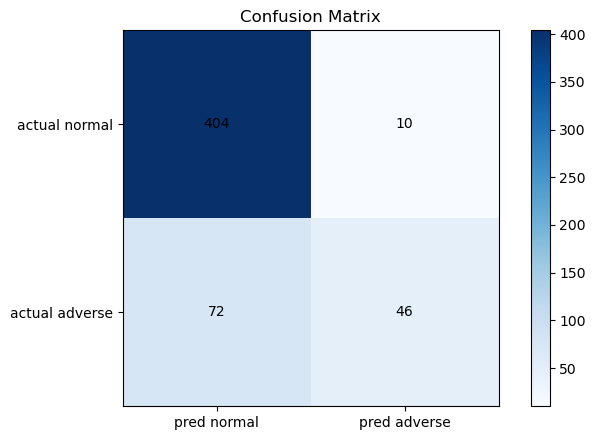

In [6]:
prf = precision_recall_f1(y_te, y_pred, positive_label=1)
cm = confusion_matrix(y_te, y_pred, labels=[0, 1])

print(f"Accuracy:  {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision: {prf['precision']:.4f}")
print(f"Recall:    {prf['recall']:.4f}")
print(f"F1:        {prf['f1']:.4f}")

plt.figure()
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["pred normal", "pred adverse"])
plt.yticks([0, 1], ["actual normal", "actual adverse"])
plt.title("Confusion Matrix")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

## 6. Visualizations

The decision-score histogram shows how far test examples fall from the learned separating hyperplane. Values above zero are predicted as suspect/pathological. The coefficient plot shows which standardized inputs receive the largest weights in the linear model.

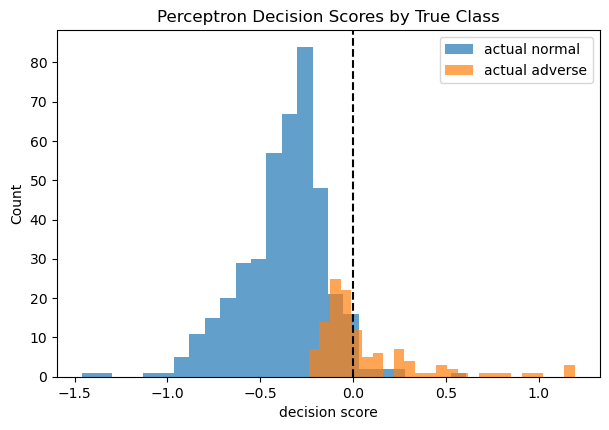

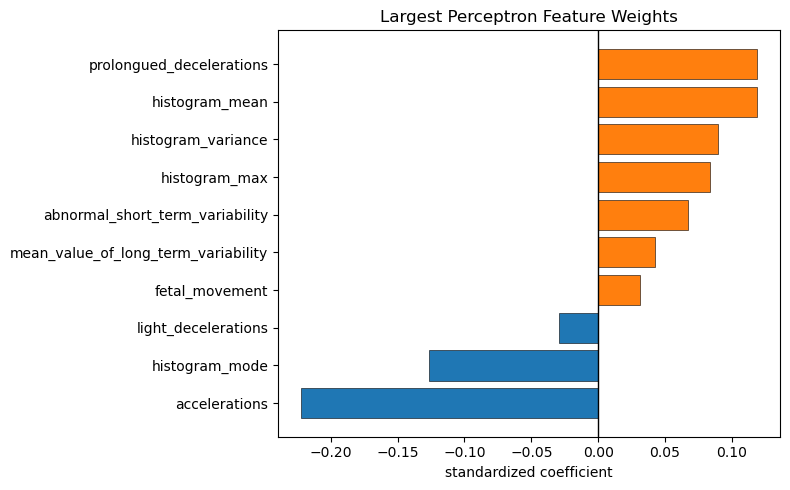

accelerations                         -0.2224
histogram_mode                        -0.1265
prolongued_decelerations               0.1189
histogram_mean                         0.1189
histogram_variance                     0.0895
histogram_max                          0.0837
abnormal_short_term_variability        0.0671
mean_value_of_long_term_variability    0.0425
fetal_movement                         0.0310
light_decelerations                   -0.0292
dtype: float64

In [7]:
# Decision score distribution by true class.
plt.figure()
plt.hist(y_score[y_te == 0], bins=25, alpha=0.7, label="actual normal")
plt.hist(y_score[y_te == 1], bins=25, alpha=0.7, label="actual adverse")
plt.axvline(0, linestyle="--", color="black")
plt.xlabel("decision score")
plt.ylabel("Count")
plt.title("Perceptron Decision Scores by True Class")
plt.legend()
plt.show()

# Largest standardized coefficients by magnitude.
coef = pd.Series(model.coef_, index=feature_names)
top_coef = coef.reindex(coef.abs().sort_values(ascending=False).head(10).index).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["tab:orange" if val > 0 else "tab:blue" for val in top_coef]
ax.barh(top_coef.index, top_coef.values, color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("standardized coefficient")
ax.set_title("Largest Perceptron Feature Weights")
plt.tight_layout()
plt.show()

top_coef.sort_values(key=abs, ascending=False).round(4)

## 7. Linear limitation: XOR

A perceptron can only learn a linear separator. XOR is the classic counterexample: no single straight line separates its two classes.

XOR accuracy = 0.50
No straight line separates XOR — the perceptron oscillates.


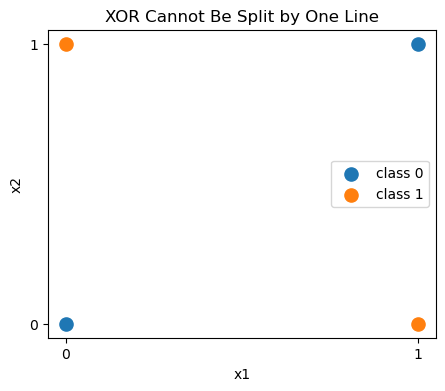

In [8]:
x_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])
p_xor = Perceptron(max_iter=500, random_state=0).fit(x_xor, y_xor)

print(f"XOR accuracy = {p_xor.score(x_xor, y_xor):.2f}")
print("No straight line separates XOR — the perceptron oscillates.")

plt.figure(figsize=(5, 4))
for cls, color in [(0, "tab:blue"), (1, "tab:orange")]:
    mask = y_xor == cls
    plt.scatter(x_xor[mask, 0], x_xor[mask, 1], s=90, label=f"class {cls}", color=color)
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR Cannot Be Split by One Line")
plt.legend()
plt.show()

## 8. Discussion

**Model performance (test set).** The printed summary below is generated from the actual run so it stays consistent with the plots.

**Scaling.** The perceptron update depends directly on feature magnitudes, so standardization is an important part of the workflow.

**Decision scores.** Examples close to zero are near the learned hyperplane and are the least confident classifications. Heavy overlap in the score histogram indicates the data is not cleanly linearly separable.

**Feature weights.** The coefficient plot is an internal linear-model diagnostic. Positive weights push predictions toward the adverse class; negative weights push toward normal.

**Limitations.** This binary merge simplifies the original three-class fetal-health task. A perceptron also cannot model nonlinear boundaries unless features are engineered into a linearly separable representation.

In [9]:
print("--- Auto-generated results summary ---")
print(f"Epochs: {model.n_iter_}")
print(f"Test accuracy: {accuracy_score(y_te, y_pred):.4f}")
print(f"Precision / recall / F1: {prf['precision']:.4f} / {prf['recall']:.4f} / {prf['f1']:.4f}")
print("Largest coefficient magnitudes:")
print(coef.abs().sort_values(ascending=False).head(10).round(4))

--- Auto-generated results summary ---
Epochs: 500
Test accuracy: 0.8459
Precision / recall / F1: 0.8214 / 0.3898 / 0.5287
Largest coefficient magnitudes:
accelerations                          0.2224
histogram_mode                         0.1265
prolongued_decelerations               0.1189
histogram_mean                         0.1189
histogram_variance                     0.0895
histogram_max                          0.0837
abnormal_short_term_variability        0.0671
mean_value_of_long_term_variability    0.0425
fetal_movement                         0.0310
light_decelerations                    0.0292
dtype: float64
